# Validación del pipeline de clasificación CNN

Este notebook tiene como objetivo validar el funcionamiento completo del pipeline de entrada utilizado en la etapa de clasificación de tumores ováricos mediante arquitecturas CNN.

In [16]:
# Importación de librerías
from pathlib import Path
import sys

from PIL import Image
import matplotlib.pyplot as plt
import torch

## 1. Configuración del entorno

Se agrega la ruta raíz del proyecto para permitir la importación de los módulos implementados dentro de la carpeta src.

In [17]:
PROJECT_DIR = Path("../..").resolve()

if str(PROJECT_DIR) not in sys.path:
    sys.path.append(str(PROJECT_DIR))

print(PROJECT_DIR)

/home/jvillanueva/projects/ovarian-tumor-ultrasound-classification


## 2. Selección de muestra

Se selecciona una imagen representativa del conjunto experimental para verificar visualmente el comportamiento de la transformación.

In [18]:
DATA_DIR = Path("../../data/processed/MMOTU_OTU_2D_experimental")

train_images = DATA_DIR / "train" / "images"

list(train_images.glob("*"))[:5]

[PosixPath('../../data/processed/MMOTU_OTU_2D_experimental/train/images/435.JPG'),
 PosixPath('../../data/processed/MMOTU_OTU_2D_experimental/train/images/185.JPG'),
 PosixPath('../../data/processed/MMOTU_OTU_2D_experimental/train/images/526.JPG'),
 PosixPath('../../data/processed/MMOTU_OTU_2D_experimental/train/images/65.JPG'),
 PosixPath('../../data/processed/MMOTU_OTU_2D_experimental/train/images/1287.JPG')]

In [19]:
from PIL import Image
from src.classification.transforms import get_classification_transforms

transform = get_classification_transforms()
img_path = list(train_images.glob("*"))[1]

print(img_path)

../../data/processed/MMOTU_OTU_2D_experimental/train/images/185.JPG


In [20]:
img = Image.open(img_path)

print("Dimensiones:", img.size)
print("Modo:", img.mode)

Dimensiones: (477, 535)
Modo: RGB


## 3. Aplicación de la transformación

La imagen original es transformada utilizando el pipeline definido.

In [21]:
x = transform(img)

print(x.shape)

torch.Size([3, 224, 224])


## 4. Comparación visual

Debido a que la imagen transformada incluye normalización para compatibilidad con modelos preentrenados, se realiza una desnormalización temporal únicamente para fines de visualización.

In [22]:
mean = torch.tensor(
    [0.485,0.456,0.406]
)

std = torch.tensor(
    [0.229,0.224,0.225]
)

img_display = (
    x.permute(1,2,0)
    * std
    + mean
)

img_display = torch.clamp(
    img_display,
    0,
    1
)

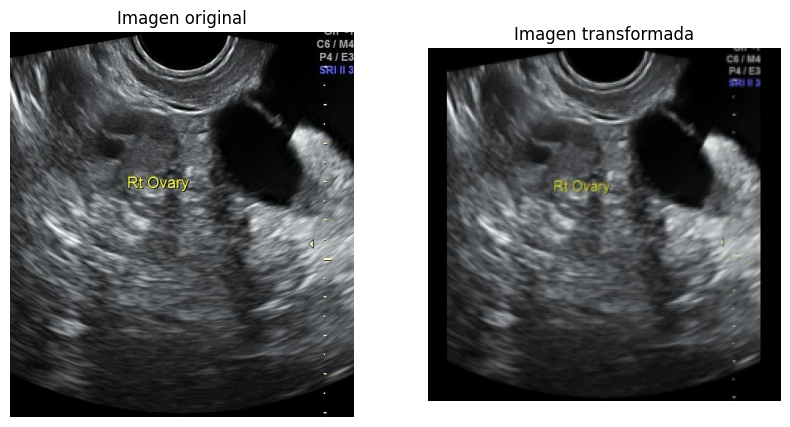

In [23]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Imagen original")
plt.axis("off")


plt.subplot(1,2,2)
plt.imshow(img_display)
plt.title("Imagen transformada")
plt.axis("off")


plt.show()

## 5. Validación de consistencia dimensional

Para confirmar que la transformación funciona independientemente de las dimensiones originales, se evalúan múltiples imágenes del conjunto.

In [24]:
sample_paths = list(train_images.glob("*"))[:10]

for path in sample_paths:
    
    img = Image.open(path)
    tensor = transform(img)

    print(
        path.name,
        tensor.shape
    )

435.JPG torch.Size([3, 224, 224])
185.JPG torch.Size([3, 224, 224])
526.JPG torch.Size([3, 224, 224])
65.JPG torch.Size([3, 224, 224])
1287.JPG torch.Size([3, 224, 224])
1034.JPG torch.Size([3, 224, 224])
438.JPG torch.Size([3, 224, 224])
398.JPG torch.Size([3, 224, 224])
1372.JPG torch.Size([3, 224, 224])
100.JPG torch.Size([3, 224, 224])


## 6. Validación del flujo de carga de datos

Además de verificar individualmente las transformaciones aplicadas a las imágenes, se valida el funcionamiento del flujo completo de carga utilizado durante el entrenamiento.

In [25]:
from src.classification.dataset import MMOTUClassificationDataset
CSV_PATH = (
    PROJECT_DIR /
    "configs" /
    "splits" /
    "mmotu_experimental_split_standard.csv"
)

DATA_PATH = (
    PROJECT_DIR /
    "data" /
    "processed" /
    "MMOTU_OTU_2D_experimental"
)

## 7. Validación del Dataset de clasificación

Luego de verificar individualmente la transformación de las imágenes, se valida el flujo completo de carga de datos mediante una implementación basada en PyTorch Dataset.

In [26]:
from src.classification.dataset import (MMOTUClassificationDataset)

train_dataset = MMOTUClassificationDataset(
    csv_file=CSV_PATH,
    image_dir=DATA_PATH,
    split="train",
    transform=transform
)

print(
    "Número de muestras:",
    len(train_dataset)
)

Número de muestras: 800


## 8. Verificación de una muestra individual

Se inspecciona una muestra del dataset para verificar la correspondencia entre la imagen procesada y su etiqueta asociada.

In [27]:
image, label = train_dataset[0]

print("Dimensión imagen:", image.shape)
print("Etiqueta:", label)

Dimensión imagen: torch.Size([3, 224, 224])
Etiqueta: 0


## 9. Validación del DataLoader

El entrenamiento de modelos CNN requiere procesar las imágenes en lotes (batches). Por ello, se verifica la generación correcta de lotes mediante el DataLoader de PyTorch.

In [28]:
from src.classification.dataloader import (create_dataloader)

train_loader = create_dataloader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

In [29]:
images, labels = next(iter(train_loader))

print("Dimensión batch imágenes:", images.shape)
print("Dimensión batch etiquetas:", labels.shape)

Dimensión batch imágenes: torch.Size([32, 3, 224, 224])
Dimensión batch etiquetas: torch.Size([32])


## 10. Integración con arquitectura ResNet50

Luego de validar el flujo de preparación de datos, se verifica la compatibilidad del pipeline con una arquitectura CNN seleccionada para el benchmark.

Se utiliza ResNet50 con pesos preentrenados mediante transferencia de aprendizaje. La capa clasificadora original, diseñada para 1000 categorías de ImageNet, es reemplazada para adaptarla al problema binario:

- Clase 0: benigno.
- Clase 1: maligno.

In [32]:
from src.classification.models import (create_resnet50_classifier)

model = create_resnet50_classifier(
    pretrained=True,
    num_classes=2,
    freeze_backbone=False
)

model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

## 4. Verificación del tamaño de entrada

Se obtiene un lote de imágenes para comprobar que las dimensiones generadas coinciden con la entrada esperada por ResNet50.

In [33]:
images, labels = next(iter(train_loader))

print("Imágenes:", images.shape)
print("Etiquetas:", labels.shape)

Imágenes: torch.Size([32, 3, 224, 224])
Etiquetas: torch.Size([32])


## 5. Evaluación del forward pass

Finalmente, se realiza una propagación hacia adelante utilizando un batch real del conjunto experimental.

In [34]:
outputs = model(images)

print(outputs.shape)

torch.Size([32, 2])
